**Libraries**

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf
from scipy.stats import norm
import sympy as sp
from datetime import *

# **Black & Scholes Model**

### **1) Declaration**

In [43]:
s = 100
k = 100
t = 2
sigma = 0.2
r = 0.01
type = 'Call'

### **2) Pricing with B&S Model**

In [44]:
def BS_Model(s, k, sigma, t, r, type = 'Call'):
    d1 = (np.log(s/k)+(r+0.5*(sigma)**2)*t)/(sigma*np.sqrt(t))
    d2 = d1 - sigma*np.sqrt(t)
    
    
    if type == 'Call':
        n1 = norm.cdf(d1)
        n2 = norm.cdf(d2)
        price = s*n1-k*np.exp(-r*t)*n2
        
    if type == 'Put':
        n1 = norm.cdf(-d1)
        n2 = norm.cdf(-d2)
        price = k * np.exp(-r*t) * n2 - s * n1
    
    return price

In [45]:
BS_Model(100, 80, 0.2, 4, 0, 'Put')

np.float64(6.391183524514435)

# **Greeks**

## **Delta**

$$\Delta = \frac{\partial V}{\partial S}$$

$$\Delta_{\text{call}} = \Phi(d_1)$$

$$\Delta_{\text{put}} = -\Phi(-d_1)$$


In [46]:
def delta(s, k, sigma, t, r, type = 'Call'):
    d1 = (np.log(s/k)+(r+0.5*(sigma)**2)*t)/(sigma*np.sqrt(t))
    n1 = norm.cdf(d1)
    
    if type == 'Call':
        delt = n1
    
    if type == 'Put':
        delt = n1-1
        
    return delt
        

### **Gamma**

$$\Gamma = \frac{\partial^2 V}{\partial S^2}$$

$$\Gamma_{\text{call}} = \Gamma_{\text{put}} = \frac{\Phi'(d_1)}{S \cdot \sigma \cdot \sqrt{T-t}}$$


In [47]:
def gamma(s, k, sigma, t, r, type = 'Call'):
    d1 = (np.log(s/k)+(r+0.5*(sigma)**2)*t)/(sigma*np.sqrt(t))
    n1 = norm.pdf(d1)

    gamm = n1/(s * sigma * np.sqrt(t))

        
    return gamm

### **Vega**

$$\nu = \frac{\partial V}{\partial \sigma}$$

$$\nu_{\text{call}} = \nu_{\text{put}} = \Phi'(d_1) \cdot S \cdot \sigma \cdot \sqrt{T - t}$$


In [48]:
def vega(s, k, sigma, t, r, type = 'Call'):
    d1 = (np.log(s/k)+(r+0.5*(sigma)**2)*t)/(sigma*np.sqrt(t))
    n1 = norm.pdf(d1)

    veg = s * n1 * np.sqrt(t)

        
    return veg

### **Theta**

$$\theta = \frac{\partial V}{\partial t}$$

$$\theta_{\text{call}} = -\frac{S \cdot \Phi'(d_1) \cdot \sigma}{2 \cdot \sqrt{T-t}} - r \cdot K \cdot e^{-r \cdot (\sqrt{T-t})} \cdot \phi(d_2)$$

$$\theta_{\text{put}} = -\frac{S \cdot \Phi'(d_1) \cdot \sigma}{2 \cdot \sqrt{T-t}} + r \cdot K \cdot e^{-r \cdot (\sqrt{T-t})} \cdot \phi(-d_2)$$


In [49]:
def theta(s, k, sigma, t, r, type = 'Call'):
    d1 = (np.log(s/k)+(r+0.5*(sigma)**2)*t)/(sigma * np.sqrt(t))
    d2 = d1 - sigma * np.sqrt(t)
    
    if type == 'Call':
        thet = -(s*norm.pdf(d1)*sigma)/(2 * np.sqrt(t)) - r * k * np.exp(-r*t)*norm.cdf(d2)
        
    if type == 'Put':
        thet = -(s*norm.pdf(d1)*sigma)/(2 * np.sqrt(t)) + r * k * np.exp(-r*t)*norm.cdf(-d2)
        
    return thet

### **Rho**

$$\rho = \frac{\partial V}{\partial r}$$

$$\rho_{\text{call}} = K \cdot (T - t) e^{-r\sqrt{T-t}} \cdot \Phi(d_2)$$

$$\rho_{\text{put}} = -K \cdot (T - t) e^{-r\sqrt{T-t}} \cdot \Phi(-d_2)$$


In [50]:
def rho(s, k, sigma, t, r, type = 'Call'):
    d1 = (np.log(s/k)+(r+0.5*(sigma)**2)*t)/(sigma * np.sqrt(t))
    d2 = d1 - sigma * np.sqrt(t)
    
    if type == 'Call':
        rh = k*t*np.exp(-r*t)*norm.cdf(d2)
        
    if type == 'Put':
        rh = -k*t*np.exp(-r*t)*norm.cdf(-d2)
        
    return rh

## ***Concat Greeks***

In [51]:
def greeks(s, k, sigma, t, r, type = 'Call'):
    delt = delta(s, k, sigma, t, r, type = 'Call')
    gamm = gamma(s, k, sigma, t, r, type = 'Call')
    thet = theta(s, k, sigma, t, r, type = 'Call')
    veg = vega(s, k, sigma, t, r, type = 'Call')
    rh = rho(s, k, sigma, t, r, type = 'Call')
    
    df = pd.DataFrame({'Values':[delt, gamm, thet, veg, rh]})
    df.index = ['Delta', 'Gamma', 'Théta', 'Véga', 'Rhô']
    
    return df

In [52]:
greeks(100, 105, 0.2, 2, 0, 'Call')

,Values
Delta,0.487604
Gamma,0.014098
Théta,-2.819586
Véga,56.391719
Rhô,79.126038


C:\Users\oussa\AppData\Local\Temp\ipykernel_13784\3641070535.py:2: RuntimeWarning: divide by zero encountered in log
  d1 = (np.log(s/k)+(r+0.5*(sigma)**2)*t)/(sigma*np.sqrt(t))
C:\Users\oussa\AppData\Local\Temp\ipykernel_13784\2072067523.py:5: RuntimeWarning: invalid value encountered in scalar divide
  gamm = n1/(s * sigma * np.sqrt(t))


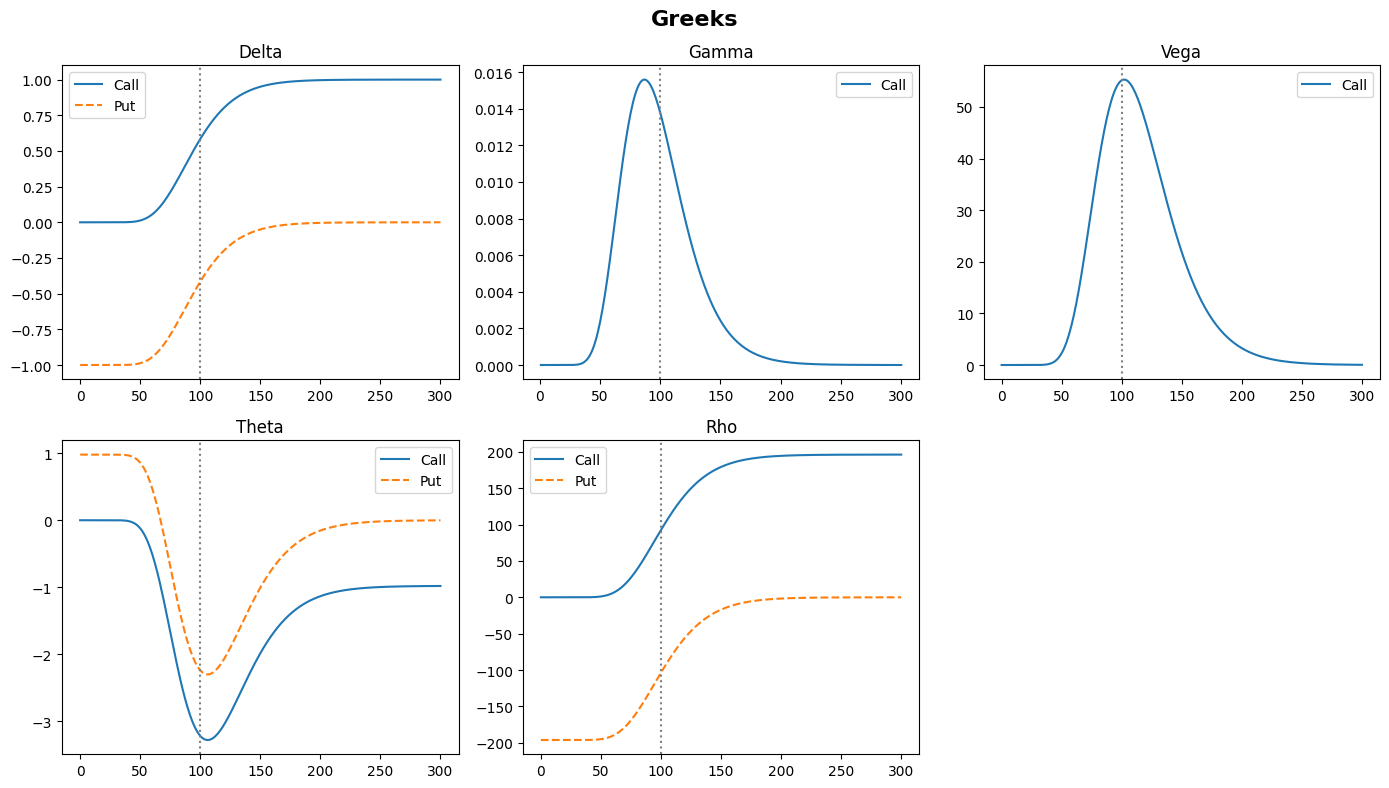

In [53]:
S = np.linspace(0, 300, 300)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Greeks', fontsize=16, fontweight='bold')

params = (S, k, sigma, t, r)

data = [
    ('Delta',  [delta(s, k, sigma, t, r, 'Call') for s in S],  [delta(s, k, sigma, t, r, 'Put') for s in S]),
    ('Gamma',  [gamma(s, k, sigma, t, r) for s in S],          None),
    ('Vega',   [vega(s, k, sigma, t, r) for s in S],           None),
    ('Theta',  [theta(s, k, sigma, t, r, 'Call') for s in S],  [theta(s, k, sigma, t, r, 'Put') for s in S]),
    ('Rho',    [rho(s, k, sigma, t, r, 'Call') for s in S],    [rho(s, k, sigma, t, r, 'Put') for s in S]),
]

axes = axes.flatten()

for i, (name, call, put) in enumerate(data):
    axes[i].plot(S, call, label='Call')
    if put:
        axes[i].plot(S, put, label='Put', linestyle='--')
    axes[i].set_title(name)
    axes[i].legend()
    axes[i].axvline(k, color='grey', linestyle=':')

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()
